In [1]:
import mg5qs_import as qs
from pathlib import Path 

In [2]:
LHE = Path('/home/leo/MadStats/mg5qs/output/cledq__3332_SM_small/Events/run_01/unweighted_events.lhe')
result, four_momenta, status = qs.generate_vals(15, LHE)


 *------------------------------------------------------------------------------------* 
 |                                                                                    | 
 |  *------------------------------------------------------------------------------*  | 
 |  |                                                                              |  | 
 |  |                                                                              |  | 
 |  |   PPP   Y   Y  TTTTT  H   H  III    A      Welcome to the Lund Monte Carlo!  |  | 
 |  |   P  P   Y Y     T    H   H   I    A A     This is PYTHIA version 8.311      |  | 
 |  |   PPP     Y      T    HHHHH   I   AAAAA    Last date of change:  8 Mar 2024  |  | 
 |  |   P       Y      T    H   H   I   A   A                                      |  | 
 |  |   P       Y      T    H   H  III  A   A    Now is 19 Feb 2025 at 18:03:37    |  | 
 |  |                                                                              |  | 
 |  |   Program docu

In [3]:
import pandas as pd
import numpy as np

In [4]:
df_stat = pd.DataFrame(status, columns = result['fields'].split(','))
df_mom = pd.DataFrame(four_momenta, columns=['px','py','pz','E'])
df_mom['pT'] = np.sqrt((df_mom['px']**2)+(df_mom['py']**2))
df = pd.concat([df_stat, df_mom], axis=1)
df

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,pT
0,1,306,-23,0,1,235,0,-24,90,308,...,15,22,1,1,0,-34.573403,11.193625,3.928253,36.595168,36.340300
1,1,308,-51,0,1,306,0,15,90,531,...,16,-12,0,1,1,-34.573402,11.193624,3.928253,36.595167,36.340300
2,2,374,-23,0,1,292,0,-24,90,376,...,15,22,1,1,0,9.283297,-13.500727,-11.473151,20.080841,16.384421
3,2,376,-51,0,1,374,0,15,90,705,...,16,-211,0,1,1,9.281914,-13.495134,-11.472846,20.076267,16.379028
4,3,32,-23,0,1,21,0,-24,90,34,...,15,22,1,1,0,-26.096676,-19.915535,-42.690712,53.882462,32.827809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14243,9997,705,-23,0,1,540,0,-24,90,707,...,15,22,1,1,0,-23.255340,18.766489,16.500585,34.182145,29.882971
14244,9997,707,-51,0,1,705,0,15,90,1246,...,16,-211,0,1,1,-23.255339,18.766488,16.500583,34.182142,29.882969
14245,9998,102,-23,0,1,77,0,-24,90,230,...,16,-12,0,1,0,-7.560999,11.701386,-0.483730,14.052859,13.931659
14246,9999,186,-23,0,1,139,0,-24,90,325,...,16,-211,0,1,0,-11.606319,34.931168,-120.796705,126.292893,36.808873


In [5]:
df[df['EVENT']==df[df['CHAININDEX']==df['CHAININDEX'].max()]['EVENT'].iloc[0]] # find the event with the longest chain

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,pT
8566,6004,5,-23,0,1,3,4,1,-2,9,...,15,15,1,1,0,5.110847,18.873824,100.113998,102.021137,19.553567
8567,6004,9,-44,0,1,5,5,15,15,14,...,15,15,1,1,1,3.696799,14.733992,10.266431,18.420482,15.190682
8568,6004,14,-44,0,1,9,9,15,15,23,...,15,15,1,1,2,3.220171,13.893643,7.826468,16.365028,14.261936
8569,6004,23,-44,0,1,14,14,15,15,37,...,15,15,1,1,3,2.208637,15.128643,7.306676,17.038168,15.289013
8570,6004,37,-44,0,1,23,23,15,15,48,...,15,15,1,1,4,1.756781,15.717108,7.013695,17.391475,15.814985
8571,6004,48,-44,0,1,37,37,15,15,64,...,15,15,1,1,5,1.758541,15.694104,6.969835,17.353204,15.792320
8572,6004,64,-44,0,1,48,48,15,15,77,...,15,15,1,1,6,2.105461,15.473737,7.088045,17.241450,15.616321
8573,6004,77,-44,0,1,64,64,15,15,94,...,15,15,1,1,7,2.118371,15.483435,7.104089,17.258333,15.627676
8574,6004,94,-44,0,1,77,77,15,15,194,...,15,15,1,1,8,1.848902,15.287648,7.250427,17.113067,15.399047
8575,6004,194,-44,0,1,94,94,15,15,283,...,15,15,1,1,9,1.896323,15.337901,7.215227,17.148308,15.454683


As a first try, we can simpely compare the beggining of a chain to its end and see which has larger pT. We know (by construction) that the end of the chain will always have DUPLICATED=0. Simularly, the beggining element will always have a chain index of 0. So our condations are if not duplicated **or** not chainindex (i.e. ==0).

In [6]:
df_begend = df[np.logical_xor(df['CHAININDEX']==0, df['DUPLICATED']==0)]
df_begend

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,pT
0,1,306,-23,0,1,235,0,-24,90,308,...,15,22,1,1,0,-34.573403,11.193625,3.928253,36.595168,36.340300
1,1,308,-51,0,1,306,0,15,90,531,...,16,-12,0,1,1,-34.573402,11.193624,3.928253,36.595167,36.340300
2,2,374,-23,0,1,292,0,-24,90,376,...,15,22,1,1,0,9.283297,-13.500727,-11.473151,20.080841,16.384421
3,2,376,-51,0,1,374,0,15,90,705,...,16,-211,0,1,1,9.281914,-13.495134,-11.472846,20.076267,16.379028
4,3,32,-23,0,1,21,0,-24,90,34,...,15,22,1,1,0,-26.096676,-19.915535,-42.690712,53.882462,32.827809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14237,9992,375,-51,0,1,373,0,15,90,678,...,16,-12,0,1,1,22.754657,-14.492752,-35.721730,44.799710,26.978033
14238,9993,332,-23,0,1,236,0,-24,90,334,...,15,22,1,1,0,-29.573013,-15.352244,26.839271,42.822409,33.320482
14239,9993,334,-51,0,1,332,0,15,90,685,...,16,-14,0,1,1,-22.327538,-11.447504,23.117125,34.163189,25.091120
14243,9997,705,-23,0,1,540,0,-24,90,707,...,15,22,1,1,0,-23.255340,18.766489,16.500585,34.182145,29.882971


Itterating through the data frame could be elimated by encoding the pT of the first partent of each particle on the C++ side, but this would overspecilize that routine to this particular task. I have chosen to leave that general at the expence of the effishance of this inquary.

In [7]:
chains = {}
for i,r in df_begend.iterrows():
    key = (int(r['EVENT']), int(r['CHAIN']))
    if key not in chains:
        chains[key] = []
    chains[key].append(r['pT']) # the physics is causal, so we can always depend on the order being [pT_first, pT_last]

In [8]:
begend = np.zeros((len(chains), 2))
for i,v in enumerate(chains.values()):
    begend[i] = v

In [9]:
sum(begend[:,1]/begend[:,0]>1)/begend.shape[0] # number of times pT increaced (proporation)

np.float64(0.04711458042932813)

In [10]:
import matplotlib.pyplot as plt

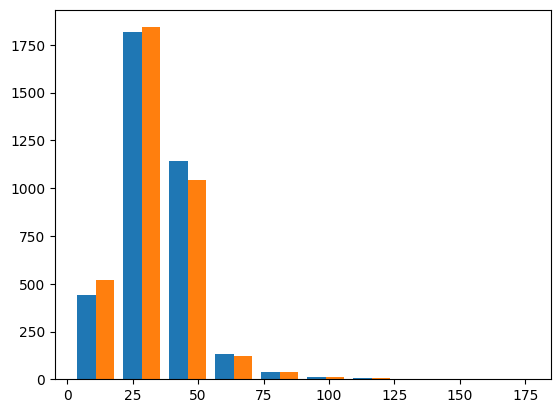

In [11]:
plt.hist(begend)
plt.show()

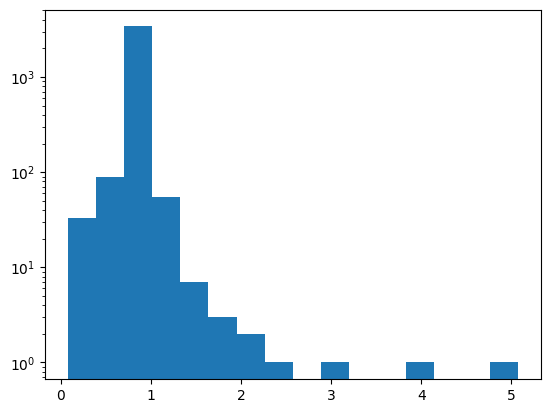

In [24]:
plt.hist(begend[:,1]/begend[:,0], bins=16)
plt.yscale('log')
plt.show()

In [13]:
np.sum(np.abs(1-(begend[:,1]/begend[:,0]))>0.05)/begend.shape[0] # percent of events for which init and final pT is within 5% of origtional

np.float64(0.12517424031223864)

This all begs the question, what if we normalize by change in magnatude of p? But this is the same as asking how the azimuthal angle will change. So lets compute that and take a look.

In [14]:
df_begend = df_begend.copy()
df_begend['azimuthal_angle'] = np.arctan2(df_begend['py'], df_begend['px'])

In [15]:
df_begend 

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,pT,azimuthal_angle
0,1,306,-23,0,1,235,0,-24,90,308,...,22,1,1,0,-34.573403,11.193625,3.928253,36.595168,36.340300,2.828479
1,1,308,-51,0,1,306,0,15,90,531,...,-12,0,1,1,-34.573402,11.193624,3.928253,36.595167,36.340300,2.828479
2,2,374,-23,0,1,292,0,-24,90,376,...,22,1,1,0,9.283297,-13.500727,-11.473151,20.080841,16.384421,-0.968431
3,2,376,-51,0,1,374,0,15,90,705,...,-211,0,1,1,9.281914,-13.495134,-11.472846,20.076267,16.379028,-0.968307
4,3,32,-23,0,1,21,0,-24,90,34,...,22,1,1,0,-26.096676,-19.915535,-42.690712,53.882462,32.827809,-2.489732
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14237,9992,375,-51,0,1,373,0,15,90,678,...,-12,0,1,1,22.754657,-14.492752,-35.721730,44.799710,26.978033,-0.567121
14238,9993,332,-23,0,1,236,0,-24,90,334,...,22,1,1,0,-29.573013,-15.352244,26.839271,42.822409,33.320482,-2.662758
14239,9993,334,-51,0,1,332,0,15,90,685,...,-14,0,1,1,-22.327538,-11.447504,23.117125,34.163189,25.091120,-2.667831
14243,9997,705,-23,0,1,540,0,-24,90,707,...,22,1,1,0,-23.255340,18.766489,16.500585,34.182145,29.882971,2.462613


In [16]:
chains_ang = {}
for i,r in df_begend.iterrows():
    key = (int(r['EVENT']), int(r['CHAIN']))
    if key not in chains_ang:
        chains_ang[key] = []
    chains_ang[key].append(r['azimuthal_angle']) 
    
phi_begend = np.zeros((len(chains_ang), 2))
for i,v in enumerate(chains_ang.values()):
    phi_begend[i] = v

phi_begend

array([[ 2.82847904,  2.82847904],
       [-0.96843118, -0.96830727],
       [-2.489732  , -2.48782862],
       ...,
       [-0.56712061, -0.56712061],
       [-2.66275828, -2.66783052],
       [ 2.46261282,  2.46261283]])

In [17]:
max(np.abs(phi_begend[:,0]-phi_begend[:,1])) # this leaves begind some wrapping errors (2pi->0)

np.float64(6.272546236850394)

In [18]:
a=np.abs(phi_begend[:,0]-phi_begend[:,1])
b=np.abs(np.abs(phi_begend[:,0]-phi_begend[:,1])-(2*np.pi))
deltaphi = np.minimum(a,b)

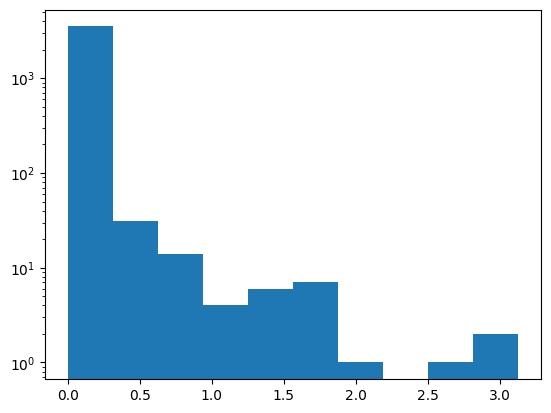

In [19]:
plt.hist(deltaphi)
plt.yscale('log')
plt.show()

The diffrence in azimuthal angle may be misleading because vectors far from the beam axis which switch axtross the transverse plane will have an inflated change in angle. We can adress this by asking about the diffrence of overall direction, but this comes at the expence of no longer being usefull for making statments about if the vector became more or less transverse. It could however be usefull in understanding if this line of inquary is even valid. Afterall, if the angle changes are very small, then there is less foundation on which to find preferance in direction. 

Yet again, we will pull out the data, this time preserving all three components of momentum.

In [35]:
chains_dir = {}
event_ids = []
for i,r in df_begend.iterrows():
    key = (int(r['EVENT']), int(r['CHAIN']))
    if key not in chains_dir:
        chains_dir[key] = []
        event_ids.append(int(r['EVENT']))
    chains_dir[key].append((r['px'], r['py'], r['pz'])) 

dir_begend = np.zeros((len(chains_dir), 2, 3))
# keys are itterated in insertion order as of py3.7 (so we can ascocate to event_ids by index)
for i,v in enumerate(chains_dir.values()): 
    dir_begend[i] = v

dot = np.einsum('ij,ij->i', dir_begend[:, 0, :], dir_begend[:, 1, :])
norms = np.linalg.norm(dir_begend[:, 0, :], axis=1) * np.linalg.norm(dir_begend[:, 1, :], axis=1)
cos_theta = np.clip(dot/norms, -1, 1) # due to fpe the results may slightly exceed bounds 
delta_theta = np.arccos(cos_theta)

In [36]:
delta_theta.min(), delta_theta.max() 

(np.float64(0.0), np.float64(2.4031403390814634))

So, sometimes the approxamations eliminate direction change entierly, and other times the particle reverses direction entierly. 

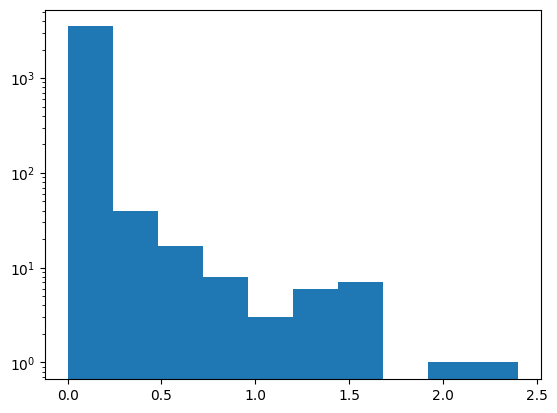

In [37]:
plt.hist(delta_theta)
plt.yscale('log')
plt.show()

Most of the time, the change is marginal. Lets try to find the event which has the largest change in direction.

In [43]:
df[df['EVENT']==event_ids[np.argmax(delta_theta)]]

,EVENT,INDEX,STATUS,ISFINAL,ISCHARGED,MOTHER1,MOTHER2,MOTHER1ID,MOTHER2ID,DAUGHTER1,...,DAUGHTER1ID,DAUGHTER2ID,DUPLICATED,CHAIN,CHAININDEX,px,py,pz,E,pT
7536,5276,401,-23,0,1,296,0,-24,90,403,...,15,22,1,1,0,-0.161659,-10.298947,-14.947643,18.239633,10.300216
7537,5276,403,-51,0,1,401,0,15,90,817,...,16,-14,0,1,1,-15.877639,4.161859,21.840885,27.378869,16.414033


In [42]:
event_ids[np.argmax(delta_theta)], df_begend.iloc[np.argmax(delta_theta)*2]['EVENT'].astype(int)

(5276, np.int64(5276))